# Initialization analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import LinearSegmentedColormap

from dlroms import * 
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import os
import sys
sys.path.insert(0, '..')
from src.blocks import Normalizer
from src.modules import *
from src.utils import *
from src.activations import *
from src.modules import *
from src.training import *

import tqdm

### Setup

In [2]:
# Upload data
datapath = os.path.join('..', 'data')
exp_rod = (
    os.path.join(datapath, 'rod_mesh.xml'), 
    os.path.join(datapath,'rod_snapshots.npz')
)
exp_shield = (
    os.path.join(datapath, 'shield_mesh.xml'), 
    os.path.join(datapath,'shield_snapshots.npz')
)
exp_gaussian = (
    os.path.join(datapath, 'gaussian_mesh.xml'), 
    os.path.join(datapath,'gaussian_snapshots.npz')
)
experiments = zip(
    ('rod','shield','gaussian'),
    (exp_rod, exp_shield, exp_gaussian)
)

# Set savepath
savepath = os.path.join('..', 'results')
if not os.path.exists(savepath):
    os.makedirs(savepath)

# Set configuration
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
np.random.seed(1)
torch.manual_seed(1)

# Select test case
(utrain, uval, utest), mesh = loadexp(*exp_gaussian)
normalizer = Normalizer(utrain = utrain)
n0 = utrain.shape[1]

# Select activations and range for the activation function parameter
activations = (
    HypAct,
    lambda alpha: LeakyReLU(alpha, 5/4)
)
thetas = np.linspace(0.1, np.pi / 6, 7) #for Hypact_{\theta}
alphas = np.linspace(5/6, 7, 7) # for LeakyRelu_{alpha,5/4}

# Select number of random trials
n_trials = 100

### Analysis w.r.t. latent dimension

In [3]:
# Select latent dimension range
latent_dims = np.arange(1,16)


def analyze_latent_dim(
    model_class, 
    activation_class, 
    act_param_range
):

    # Initialize collections for the analysis
    init_analysis_latent = dict()
    init_analysis_latent['mse_eys'] = list()
    init_analysis_latent['mse_standard'] = list()
    init_analysis_latent['sharpnesses'] = list()
    init_analysis_latent['latent_dim'] = list()

    for latent_dim in tqdm.tqdm(latent_dims):
        for act_param in act_param_range:
            # Activation function setup
            bilipactivation = activation_class(act_param) 
            bilipactivation.setup()
            # Skeleton setup
            red_dims = (utrain.shape[1], 20, latent_dim)
            # Random trials for standard random initialization
            curr_mses_standard = list()
            for _ in range(n_trials):
                sae = model_class(red_dims, bilipactivation)
                sae.standard()
                sae.to(device)
                upred = normalizer.backward(sae(normalizer.forward(utest)))
                curr_mses_standard.append(msei(euclidean)(utrue = utest, upred = upred))
            # EYS initialization
            nested_pod = NestedPOD(normalizer.forward(utrain), red_dims, bilipactivation)
            sae = model_class(red_dims, bilipactivation)
            sae.eys(nested_pod = nested_pod)
            sae.to(device)
            upred = normalizer.backward(sae(normalizer.forward(utest)))
            # Collect quantities for analysis
            init_analysis_latent['mse_eys'].append(msei(euclidean)(utrue = utest, upred = upred))
            init_analysis_latent['mse_standard'].append(np.min(curr_mses_standard))
            init_analysis_latent['sharpnesses'].append(bilipactivation.sharpness)
            init_analysis_latent['latent_dim'].append(latent_dim)
    
    return init_analysis_latent

### Analysis w.r.t. depth

In [4]:
# Collection of skeletons corresponding to increasing depths
red_dims_collection = (
    [n0, 65, 3],
    [n0, 65, 5, 3],
    [n0, 65, 9, 5, 3],
    [n0, 65, 17, 9, 5, 3],
    [n0, 65, 33, 17, 9, 5, 3]
)


def analyze_depth(
    model_class, 
    activation_class, 
    act_param_range
):

    # Initialize collections for the analysis
    init_analysis_depth = dict()
    init_analysis_depth['mse_eys'] = list()
    init_analysis_depth ['mse_standard'] = list()
    init_analysis_depth['sharpnesses'] = list()
    init_analysis_depth['depth'] = list()

    for red_dims in tqdm.tqdm(red_dims_collection):
        for act_param in act_param_range:
            # Activation function setup
            bilipactivation = activation_class(act_param) 
            bilipactivation.setup()
            # Skeleton setup
            curr_mses_standard = list()
            # Random trials for standard random initialization
            for _ in range(n_trials):
                sae = model_class(red_dims, bilipactivation)
                sae.standard()
                sae.to(device)
                upred = normalizer.backward(sae(normalizer.forward(utest)))
                curr_mses_standard.append(msei(euclidean)(utrue = utest, upred = upred))
            # EYS initialization
            nested_pod = NestedPOD(normalizer.forward(utrain), red_dims, bilipactivation)
            sae = model_class(red_dims, bilipactivation)
            sae.eys(nested_pod = nested_pod)
            sae.to(device)
            upred = normalizer.backward(sae(normalizer.forward(utest)))
            # Collect quantities for analysis
            init_analysis_depth['mse_eys'].append(msei(euclidean)(utrue = utest, upred = upred))
            init_analysis_depth['mse_standard'].append(np.min(curr_mses_standard))
            init_analysis_depth['sharpnesses'].append(bilipactivation.sharpness)
            init_analysis_depth['depth'].append(len(red_dims) - 1)

    return init_analysis_depth

### Function to generate the figure

In [5]:
def generate_figure(
    init_analysis_latent : dict, 
    init_analysis_depth : dict, 
    figure_id : str,
    param_id : str
): 

    fig, axs = plt.subplots(1, 2, figsize = (12,3.5))

    # Set up colormaps and colorscales
    depths = np.array([(len(red_dims) - 1) for red_dims in red_dims_collection])
    sharpnesses = np.unique(init_analysis_latent['sharpnesses'])
    colorscale = (sharpnesses - np.min(sharpnesses)) / (np.max(sharpnesses) - np.min(sharpnesses))
    cmap_eys = LinearSegmentedColormap.from_list("blue_to_lightblue", ["paleturquoise", "midnightblue" ] )
    colors_eys = cmap_eys(colorscale)
    cmap_standard = LinearSegmentedColormap.from_list("red_to_lightred", ["mistyrose","darkred"])
    colors_standard = cmap_standard(colorscale)

    # Plot everything for increasing sharpness
    for idx in range(len(sharpnesses)):
        curr_item_cond = init_analysis_latent['sharpnesses'] == sharpnesses[idx]
        axs[0].semilogy(
            latent_dims, 
            np.array(init_analysis_latent['mse_eys'])[curr_item_cond], 
            color = colors_eys[idx],
            marker = 'o'
        )
        axs[0].semilogy(
            latent_dims, 
            np.array(init_analysis_latent['mse_standard'])[curr_item_cond], 
            color = colors_standard[idx],
            marker = 'o'
        )
        curr_item_cond = init_analysis_depth['sharpnesses'] == sharpnesses[idx]
        axs[1].semilogy(
            depths, 
            np.array(init_analysis_depth['mse_eys'])[curr_item_cond], 
            color = colors_eys[idx],
            marker = '^'
        )
        axs[1].semilogy(
            depths, 
            np.array(init_analysis_depth['mse_standard'])[curr_item_cond], 
            color = colors_standard[idx],
            marker = '^'
        )

    # Set up formatting
    for ax, cmap in zip(axs, (cmap_eys, cmap_standard)):
        mappable = mpl.cm.ScalarMappable(norm=None, cmap=cmap)
        mappable.set_array(sharpnesses)
        ax.xaxis.set_tick_params(which = 'both', labelsize = 12)
        ax.yaxis.set_tick_params(which = 'both', labelsize = 12)
        ax.yaxis.set_tick_params(labelsize = 13, which = 'both')
        ax.grid(color='grey', which = 'both', linestyle=':', linewidth=0.3)
        ax.tick_params(axis='x', which = 'both', colors='grey')
        ax.tick_params(axis='y', which = 'both', colors='grey')
        ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))


    # Colorbar 1
    cbar_width = 0.01
    cbar1_x_pos = 0.98 - cbar_width 
    cbar_height = 0.3
    cbar_y_pos = 0.1
    cax1 = fig.add_axes([cbar1_x_pos, cbar_y_pos, cbar_width, cbar_height])
    mappable_eys = mpl.cm.ScalarMappable(norm = None, cmap = cmap_eys)
    mappable_eys.set_array(sharpnesses)
    cbar1 = fig.colorbar(mappable_eys, cax = cax1)
    cbar1.set_ticks([])
    cbar1.set_label('$\\angle(' + param_id + ')$', rotation=90, labelpad = -35, fontsize = 14)

    # Colorbar 2
    mappable_standard = mpl.cm.ScalarMappable(norm = None, cmap = cmap_standard)
    mappable_standard.set_array(sharpnesses)
    cbar2_x_pos = cbar1_x_pos + cbar_width 
    cax2 = fig.add_axes([cbar2_x_pos, cbar_y_pos, cbar_width, cbar_height])
    cbar2 = fig.colorbar(mappable_standard, cax=cax2)
    cax2.tick_params(axis='both', which='major', labelsize=11)

    # Set up titles and labels 
    axs[0].set_ylabel('$MSE_{test}$', fontsize = 15)
    axs[0].set_title('Latent dimension', fontsize = 16, pad = 10)
    axs[1].set_title('Depth', fontsize = 16, pad = 10)
    axs[0].set_xlabel('$n_2$', fontsize = 14)
    axs[1].set_xlabel('$\\# levels$ $(l)$', fontsize = 14)
    axs[1].set_ylim([2.5e0,1e3])
    plt.subplots_adjust(wspace = 0.2,)

    # Save figure
    plt.savefig(os.path.join(savepath, 'init_study' + figure_id + '.png'), bbox_inches='tight')

_sae_hypact


100%|██████████| 5/5 [00:15<00:00,  3.05s/it]


{'mse_eys': [14.701017379760742, 16.47456169128418, 19.338455200195312, 21.496503829956055, 24.063228607177734, 28.4819278717041, 39.240962982177734, 8.739455223083496, 8.852246284484863, 9.066458702087402, 9.41250228881836, 10.035003662109375, 11.45671272277832, 15.532909393310547, 4.847566604614258, 4.960380554199219, 5.102149963378906, 5.279819011688232, 5.509861469268799, 5.835446834564209, 6.399483680725098, 2.2499585151672363, 2.2868573665618896, 2.334364891052246, 2.3989479541778564, 2.4965572357177734, 2.6631991863250732, 2.97249174118042, 0.9667174816131592, 0.9714948534965515, 0.9759565591812134, 0.9822791814804077, 0.994473397731781, 1.0197625160217285, 1.0751746892929077, 0.45487090945243835, 0.45869407057762146, 0.46408504247665405, 0.47236669063568115, 0.4864705502986908, 0.5143926739692688, 0.5845962166786194, 0.18534335494041443, 0.1849224865436554, 0.1839783489704132, 0.1829489916563034, 0.18269412219524384, 0.18498171865940094, 0.19374294579029083, 0.06819602102041245

100%|██████████| 5/5 [00:11<00:00,  2.34s/it]


{'mse_eys': [14.818278312683105, 15.2482271194458, 15.989459991455078, 16.482921600341797, 16.838069915771484, 17.121458053588867, 17.368619918823242, 8.845616340637207, 9.051753044128418, 9.524182319641113, 10.004971504211426, 10.584190368652344, 11.289823532104492, 12.128741264343262, 4.937561988830566, 4.674825191497803, 4.733523845672607, 4.885518550872803, 5.1556878089904785, 5.549643516540527, 6.064482688903809, 2.2944839000701904, 2.2064952850341797, 2.2495079040527344, 2.292163372039795, 2.3345353603363037, 2.380187511444092, 2.431413412094116, 0.9847735166549683, 0.9645429253578186, 0.9951072335243225, 1.02750563621521, 1.0744496583938599, 1.1323587894439697, 1.2013555765151978, 0.4612198770046234, 0.4544929265975952, 0.4655797481536865, 0.4739837050437927, 0.4808303713798523, 0.48700132966041565, 0.4928337633609772, 0.1842191517353058, 0.18789954483509064, 0.19153863191604614, 0.19392627477645874, 0.19594159722328186, 0.19784186780452728, 0.19976916909217834, 0.06922293454408

100%|██████████| 5/5 [02:14<00:00, 26.83s/it]


{'mse_eys': [14.701019287109375, 16.47456169128418, 19.33846092224121, 21.496505737304688, 24.063232421875, 28.481962203979492, 39.24104309082031, 8.739455223083496, 8.852246284484863, 9.066458702087402, 9.41250228881836, 10.035004615783691, 11.456718444824219, 15.532937049865723, 4.8475661277771, 4.960380554199219, 5.102149486541748, 5.279819011688232, 5.509863376617432, 5.835445880889893, 6.399477481842041, 2.2499585151672363, 2.2868573665618896, 2.334364891052246, 2.3989479541778564, 2.4965579509735107, 2.6631996631622314, 2.9724934101104736, 0.9667174220085144, 0.9714948534965515, 0.9759564995765686, 0.9822794795036316, 0.9944736957550049, 1.0197622776031494, 1.075175404548645, 0.45487096905708313, 0.4586940407752991, 0.46408504247665405, 0.47236669063568115, 0.4864705801010132, 0.5143926739692688, 0.5845970511436462, 0.18534335494041443, 0.184922456741333, 0.1839783489704132, 0.1829490214586258, 0.18269412219524384, 0.18498177826404572, 0.19374312460422516, 0.06819602102041245, 0.

100%|██████████| 5/5 [02:24<00:00, 28.81s/it]


{'mse_eys': [14.818278312683105, 15.2482271194458, 15.989459991455078, 16.482921600341797, 16.838071823120117, 17.1214599609375, 17.368619918823242, 8.845616340637207, 9.051753044128418, 9.524181365966797, 10.00497055053711, 10.58419132232666, 11.289826393127441, 12.128737449645996, 4.937561988830566, 4.674825191497803, 4.733523845672607, 4.885517597198486, 5.15568733215332, 5.549643516540527, 6.064478397369385, 2.2944839000701904, 2.2064952850341797, 2.2495083808898926, 2.292163133621216, 2.3345353603363037, 2.38018798828125, 2.431412696838379, 0.9847735166549683, 0.9645429849624634, 0.9951072335243225, 1.0275053977966309, 1.074449896812439, 1.132359266281128, 1.2013550996780396, 0.461219847202301, 0.4544929265975952, 0.4655797481536865, 0.4739837050437927, 0.4808303713798523, 0.48700132966041565, 0.4928337037563324, 0.1842191517353058, 0.18789954483509064, 0.19153863191604614, 0.19392627477645874, 0.19594165682792664, 0.19784186780452728, 0.19976916909217834, 0.06922294199466705, 0.0

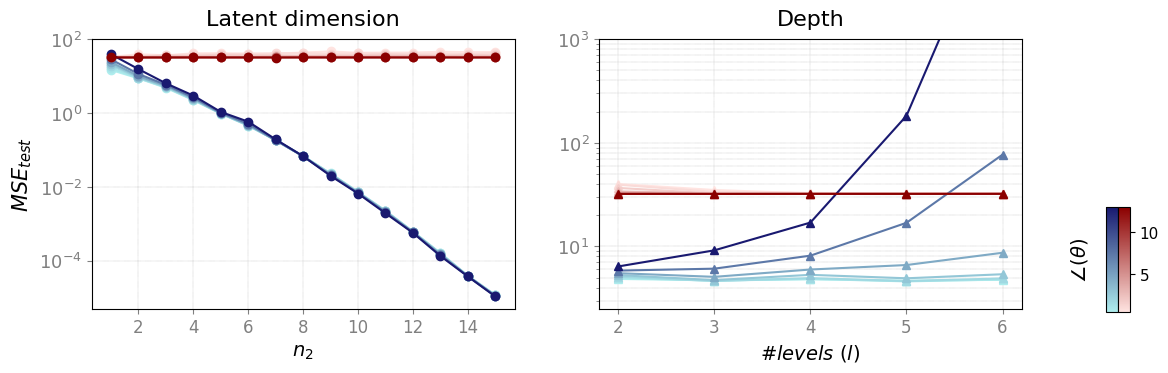

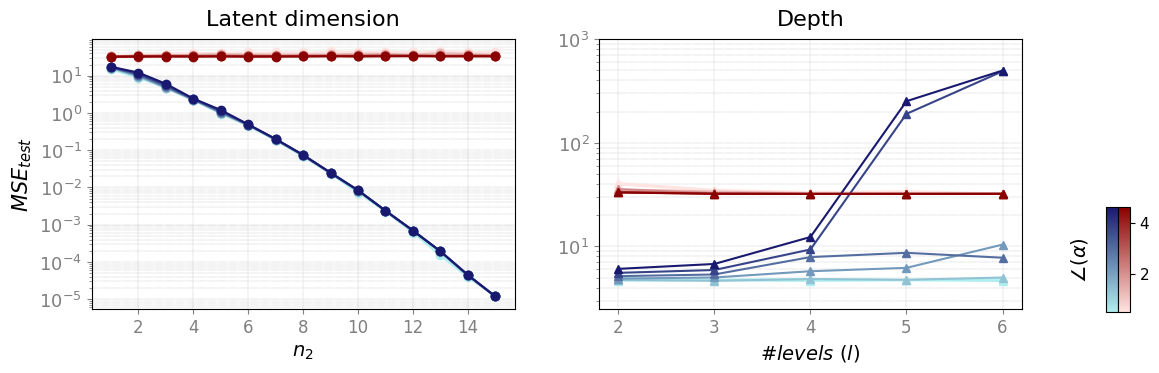

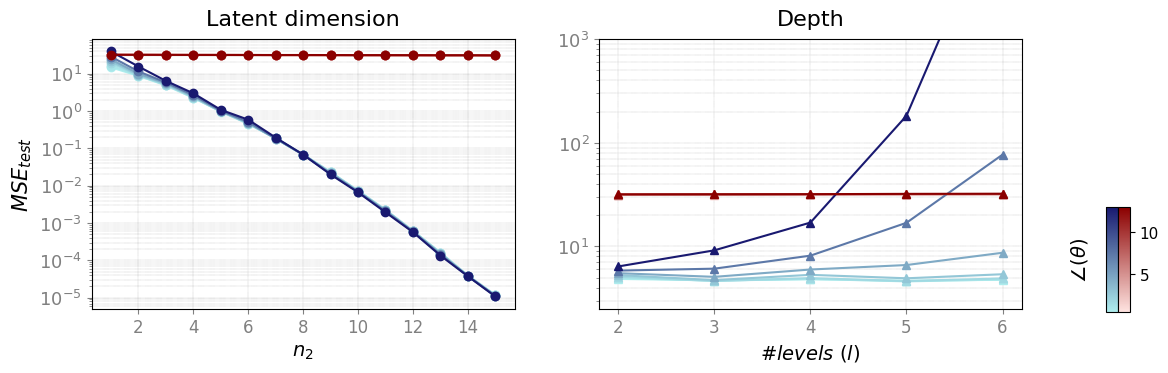

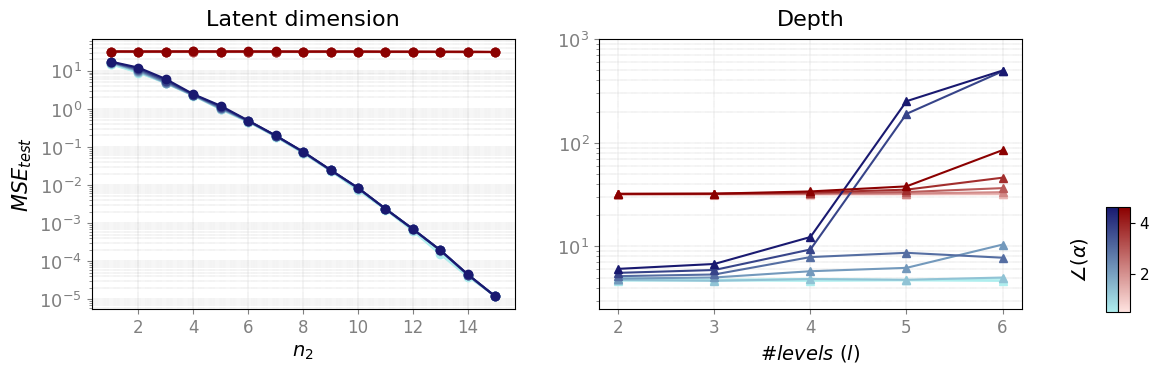

In [6]:
for model_class in (SAE, SOAE):
    for activation, act_param_range, act_name in zip(activations, (thetas, alphas), ('hypact', 'leaky')):
        figure_id =  '_' + model_class.__name__ + '_' + act_name
        figure_id = figure_id.lower()
        param_id = '\\theta' if act_name == 'hypact' else '\\alpha'
        print(figure_id)
        init_analysis_latent = analyze_latent_dim(model_class, activation, act_param_range)
        init_analysis_depth = analyze_depth(model_class, activation, act_param_range)
        print(init_analysis_latent)
        print(init_analysis_depth)
        generate_figure(init_analysis_latent, init_analysis_depth, figure_id = figure_id, param_id = param_id)